In [1]:
from ultralytics import YOLO

model_path = "../Models/yolov8n.pt"
model = YOLO(model_path)

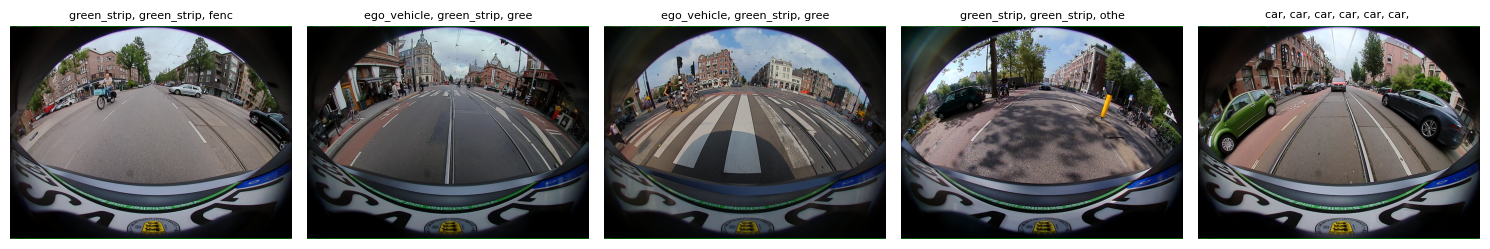

In [2]:
import os
import random
import json
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np 
from pathlib import Path


data_dir = Path.cwd().parent / "Data"

train_img_path = data_dir / "train" / "img"
train_ann_path = data_dir / "train" / "ann"


RV_images = [p for p in os.listdir(train_img_path) if "_RV" in os.path.splitext(os.path.basename(p))[0]]
test_images = random.sample(RV_images, 5)

with open("test_images.json","w") as f:
    json.dump(test_images, f)

plt.figure(figsize=(15, 10))
for i, img_name in enumerate(test_images):
    img_path = os.path.join(train_img_path, img_name)
    image = Image.open(img_path)

    # Match JSON annotation file
    ann_name = img_name + ".json"
    ann_path = os.path.join(train_ann_path, ann_name)

    label_text = "No label file"
    if os.path.exists(ann_path):
        with open(ann_path, 'r') as f:
            ann_data = json.load(f)
            if 'objects' in ann_data:
                # Get the class titles
                labels = [obj.get('classTitle', 'unknown') for obj in ann_data['objects']]
                label_text = ', '.join(labels) if labels else "No objects found"

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(label_text[:30], fontsize=8)
    plt.axis('off')
    

plt.tight_layout()
plt.show()


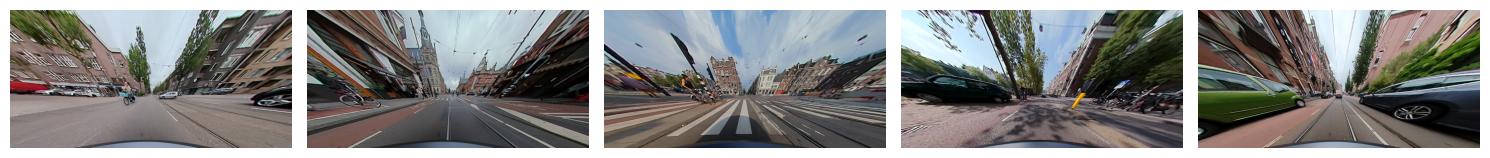

In [3]:

# Original intrinsics   
K = np.array([
    [350.0, 0.0, 640.0],  # fx, 0, cx
    [0.0, 350.0, 483.0],  # 0, fy, cy
    [0.0, 0.0, 1.0]
])
D = np.array([-0.01, 0.01, -0.001, 0.0005])  # fisheye distortion coefficients

def init_undistort_maps(K, D, image_size, balance, scale):
    w, h = image_size

    # New camera matrix with adjustable scaling
    new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
        K, D, (w, h), np.eye(3), balance=balance, new_size=(w, h), fov_scale=scale
    )

    map1, map2 = cv2.fisheye.initUndistortRectifyMap(
        K, D, np.eye(3), new_K, (w, h), cv2.CV_16SC2
    )
    return map1, map2, new_K

# Changing the scale parameters to get a better deeper view instead of the wider view that was used for the blindspot detection 
map1, map2, new_K = init_undistort_maps(K, D, (1280, 966), balance=0.1, scale=0.7)

def undistort_fisheye(image, map1, map2):
    return cv2.remap(image, map1, map2, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)

# Load your image list
with open("test_images.json", "r") as f:
    test_images = json.load(f)

# Output folder
output_folder =  Path.cwd().parent / "Notebooks" / "RV_undistorted_results"
output_folder.mkdir(exist_ok=True)

# Clear output folder
for p in output_folder.iterdir():
    if p.is_file():
        p.unlink()
os.makedirs(output_folder, exist_ok=True)

plt.figure(figsize=(15, 10))

for i, img_name in enumerate(test_images):
    img = cv2.imread(os.path.join(train_img_path, img_name))
    und = undistort_fisheye(img, map1, map2)

    h = und.shape[0]
    # crop the bottom 35% to remove the camera body (because it would sometimes detect it as a car)
    und = und[: int(h * .65) ]   

    cv2.imwrite(os.path.join(output_folder, img_name), und)
    plt.subplot(1, len(test_images), i+1)
    plt.imshow(cv2.cvtColor(und, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()



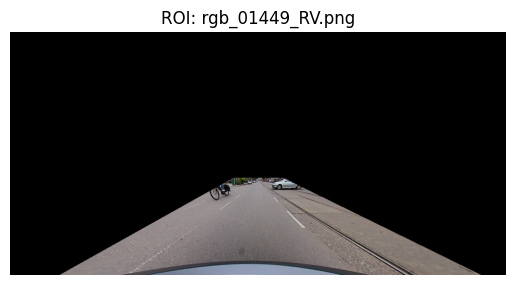

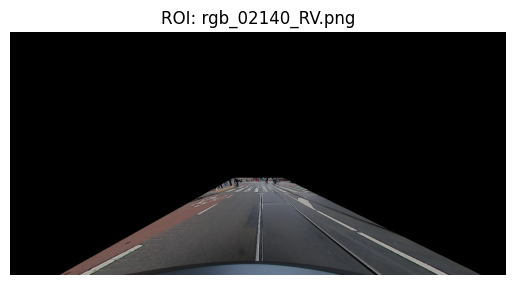

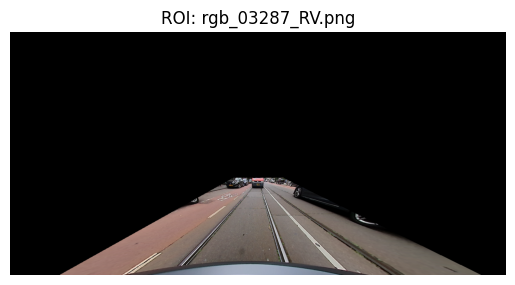

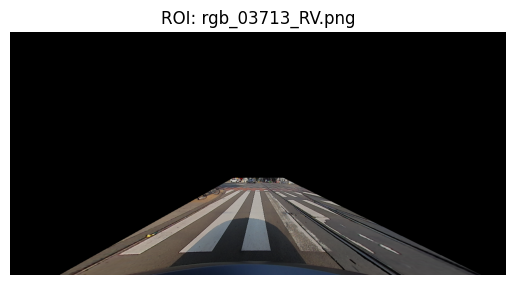

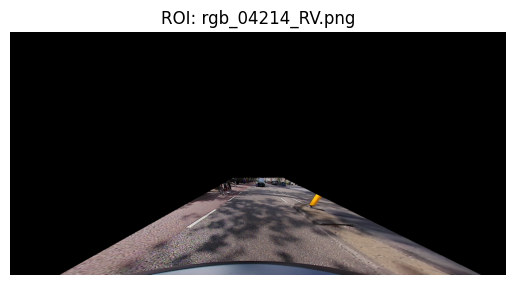

In [7]:
def region_of_interest(image):
    height, width = image.shape[:2]

    # Define polygon 
    polygon = np.array([[
        (int(0.1 * width), height),
        (int(0.45 * width), int(0.6  * height)),
        (int(0.55 * width), int(0.6  * height)),
        (int(0.95 * width), height)
    ]], dtype=np.int32)

    # Create mask
    mask = np.zeros_like(image)

    # Fill polygon with white
    cv2.fillPoly(mask, polygon, (255, 255, 255))

    # Apply mask
    masked_image = cv2.bitwise_and(image, mask)
    return masked_image

# Output folder
Masked_Results =  Path.cwd().parent / "Notebooks" / "Masked_Results"
Masked_Results.mkdir(exist_ok=True)

# Clear output folder
for p in Masked_Results.iterdir():
    if p.is_file():
        p.unlink()
os.makedirs(Masked_Results, exist_ok=True)

rv_undistorted_dir = Path.cwd().parent  / "Notebooks" / "RV_undistorted_results"

test_images = [f for f in os.listdir(rv_undistorted_dir)]
for img_file in test_images:
    img_path = os.path.join(rv_undistorted_dir, img_file)
    image = cv2.imread(img_path)
    roi_image = region_of_interest(image)  # Now passing actual image array
    roi_rgb = cv2.cvtColor(roi_image, cv2.COLOR_BGR2RGB)
    
    cv2.imwrite(os.path.join(Masked_Results, img_file), roi_image)
    plt.imshow(roi_rgb)
    plt.title(f"ROI: {img_file}")
    plt.axis('off')
    plt.show()


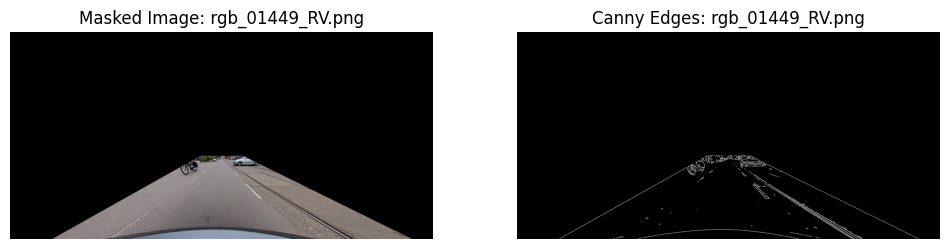

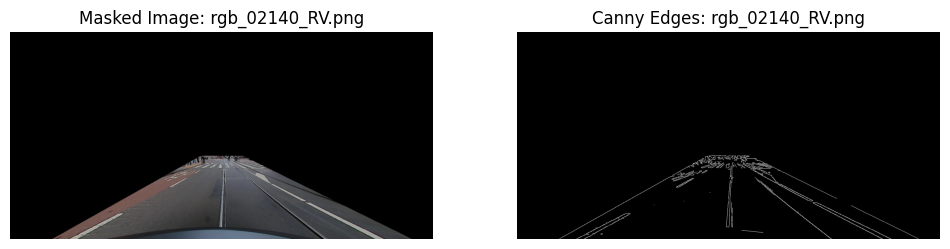

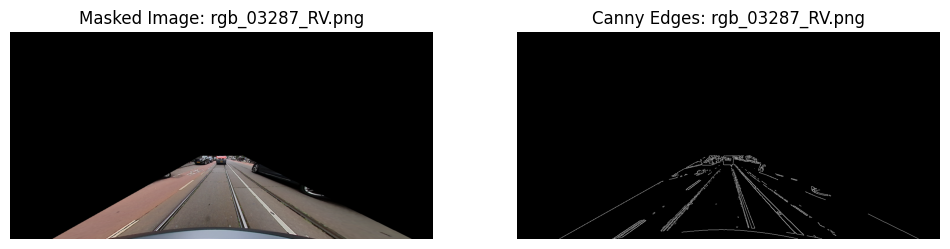

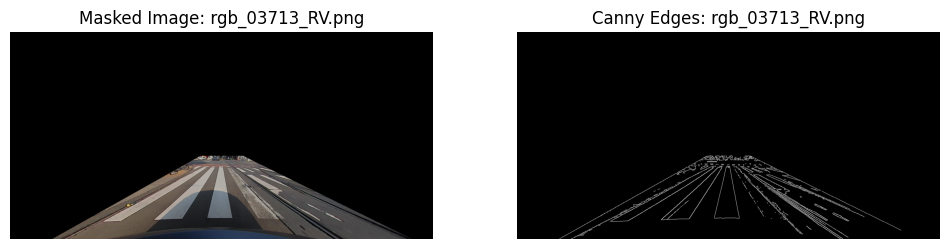

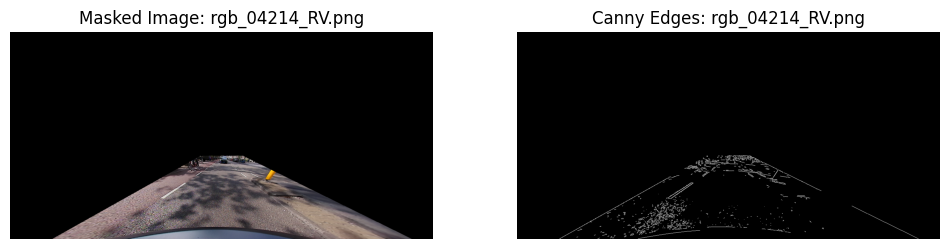

In [ ]:
for img_file in os.listdir(Masked_Results):
    img_path = os.path.join(Masked_Results, img_file)
    image = cv2.imread(str(img_path))

    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 2. Apply Canny Edge Detector
    # The thresholds 300 (low) and 400 (high) determine edge sensitivity
    edges = cv2.Canny(gray_image, 300, 400)

    # 3. Display the original masked image vs the edge detection result
    plt.figure(figsize=(12, 6))

    # Original Masked Image
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"Masked Image: {img_file}")
    plt.axis('off')

    # Canny Edge Output
    plt.subplot(1, 2, 2)
    plt.imshow(edges, cmap='gray')
    plt.title(f"Canny Edges: {img_file}")
    plt.axis('off')

    plt.show()



🔍 Running detection on: rgb_01449_RV.png

image 1/1 c:\2025-2026 project\SafeSight_Senior\Notebooks\RV_undistorted_results\rgb_01449_RV.png: 320x640 1 car, 1 motorcycle, 121.1ms
Speed: 41.6ms preprocess, 121.1ms inference, 19.1ms postprocess per image at shape (1, 3, 320, 640)
  - car             conf: 0.68
  - motorcycle      conf: 0.34


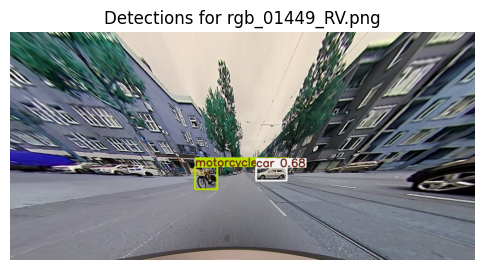


🔍 Running detection on: rgb_02140_RV.png

image 1/1 c:\2025-2026 project\SafeSight_Senior\Notebooks\RV_undistorted_results\rgb_02140_RV.png: 320x640 (no detections), 33.1ms
Speed: 2.5ms preprocess, 33.1ms inference, 0.4ms postprocess per image at shape (1, 3, 320, 640)


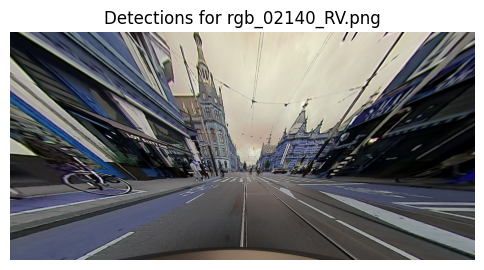


🔍 Running detection on: rgb_03287_RV.png

image 1/1 c:\2025-2026 project\SafeSight_Senior\Notebooks\RV_undistorted_results\rgb_03287_RV.png: 320x640 5 cars, 33.8ms
Speed: 1.1ms preprocess, 33.8ms inference, 0.6ms postprocess per image at shape (1, 3, 320, 640)
  - car             conf: 0.68
  - car             conf: 0.62
  - car             conf: 0.54
  - car             conf: 0.33
  - car             conf: 0.28


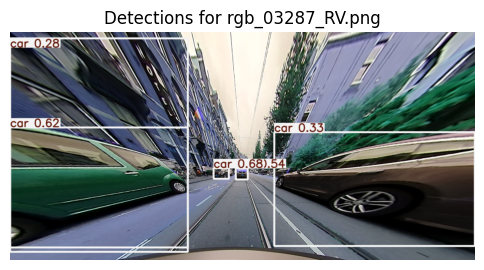


🔍 Running detection on: rgb_03713_RV.png

image 1/1 c:\2025-2026 project\SafeSight_Senior\Notebooks\RV_undistorted_results\rgb_03713_RV.png: 320x640 (no detections), 30.2ms
Speed: 1.1ms preprocess, 30.2ms inference, 0.3ms postprocess per image at shape (1, 3, 320, 640)


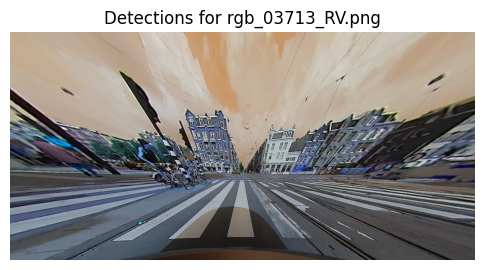


🔍 Running detection on: rgb_04214_RV.png

image 1/1 c:\2025-2026 project\SafeSight_Senior\Notebooks\RV_undistorted_results\rgb_04214_RV.png: 320x640 1 person, 3 cars, 27.4ms
Speed: 1.4ms preprocess, 27.4ms inference, 0.7ms postprocess per image at shape (1, 3, 320, 640)
  - car             conf: 0.66
  - car             conf: 0.46
  - person          conf: 0.44
  - car             conf: 0.40


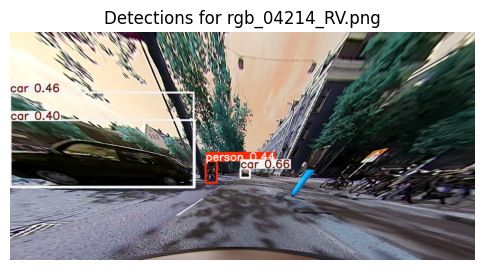

In [5]:
# Folder with undistorted RV PNGs
rv_undistorted_dir = Path.cwd().parent  / "Notebooks" / "RV_undistorted_results"

test_images = [f for f in os.listdir(rv_undistorted_dir)]
for img_file in test_images:
    img_path = os.path.join(rv_undistorted_dir, img_file)
    print(f"\n🔍 Running detection on: {img_file}")
    results = model(img_path, verbose=True)  
    
    # results[0] contains one image's detection info
    for box in results[0].boxes:
        cls_id = int(box.cls)                     # class ID
        conf = float(box.conf)                    # confidence
        cls_name = model.names[cls_id]            # class name (like car, person, etc.)
        print(f"  - {cls_name:<15} conf: {conf:.2f}")

    plotted = results[0].plot()                   # draws boxes + labels on image
    plt.figure(figsize=(6, 4))
    plt.imshow(plotted)
    plt.title(f"Detections for {img_file}")
    plt.axis('off')
    plt.show()
